In [1]:
import argparse
import json
import logging
import os
import pickle
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder as SkOHE, StandardScaler
from lifelines import CoxPHFitter, KaplanMeierFitter
import xgboost as xgb
import lightgbm as lgb

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)
sns.set_theme(style="whitegrid", font_scale=1.1)



In [2]:
def create_spark(app="FannieMae_V3", driver_mem="24g"):
    from pyspark.sql import SparkSession
    return (
        SparkSession.builder.appName(app)
        .config("spark.driver.memory",                          driver_mem)
        .config("spark.serializer",
                "org.apache.spark.serializer.KryoSerializer")
        .config("spark.kryoserializer.buffer.max",              "512m")
        .config("spark.sql.adaptive.enabled",                   "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled","true")
        .config("spark.sql.adaptive.skewJoin.enabled",          "true")
        .config("spark.sql.shuffle.partitions",                 "400")
        .config("spark.sql.autoBroadcastJoinThreshold",         "100m")
        .config("spark.sql.parquet.filterPushdown",             "true")
        .config("spark.memory.offHeap.enabled",                 "true")
        .config("spark.memory.offHeap.size",                    "8g")
        .getOrCreate()
    )

In [3]:
#spark = create_spark()

In [4]:
NUMERIC_FEATURES = [
    "fico", "orig_interest_rate", "current_interest_rate",
    "refi_incentive", "refi_incentive_pos",
    "rate_spread_to_10y", "spread_pos",
    "orig_ltv", "dti", "orig_upb", "upb_fraction", "equity_proxy",
    "loan_age", "age_sq", "burnout", "pct_term_elapsed",
    "orig_loan_term", "remaining_months_to_mat", "rate_duration",
    "burnout_x_refi", "fico_x_refi", "ltv_x_refi",
    "ph_delinq_count", "excess_principal", "gs10_monthly", "logit_rate_spread_to_10y"
]

CATEGORICAL_FEATURES = [
    "channel", "loan_purpose", "property_type", "occupancy_status",
    "fico_bucket", "seasoning_bucket", "month_of_year", "vintage_year",
]

BINARY_FEATURES = [
    "high_ltv", "term_15y", "is_refi", "is_cashout", "is_io",
    "has_ppm", "modified", "is_investor", "is_high_bal",
    "first_time_buyer", "in_forbearance", "has_deferral",
    "is_judicial_state", "is_hltv_refi",
]
TARGET_COL = "smm_target"

In [28]:
import pyarrow.dataset as ds

def read_first_n_rows(path, n=100_000):
    dataset = ds.dataset(path, format="parquet")

    batches = []
    total = 0

    for batch in dataset.to_batches(batch_size=min(n, 1_000_000)):
        pdf = batch.to_pandas()
        batches.append(pdf)

        total += len(pdf)
        if total >= n:
            break

    return pd.concat(batches, ignore_index=True).head(n)


def load_raw_data(out_path: str, sample_frac: float = 0.1):
    export_dir = os.path.join(out_path, "exported")

    with open(os.path.join(export_dir, "columns.json")) as fh:
        col_meta = json.load(fh)

    log.info("Loading raw train Parquet …")
    #train_pd = pd.read_parquet(os.path.join(export_dir, "train_raw.parquet"))
    train_pd = read_first_n_rows(os.path.join(export_dir, "train_raw.parquet"), 1_000)
    log.info("Loading raw test Parquet …")
    #test_pd = pd.read_parquet(os.path.join(export_dir, "test_raw.parquet"))
    test_pd = read_first_n_rows(os.path.join(export_dir, "test_raw.parquet"), 7_000_000)

    log.info("Full sizes: train={:,}, test={:,}".format(len(train_pd), len(test_pd)))

    if sample_frac < 1.0:
        train_pd = train_pd.sample(frac=sample_frac, random_state=SEED)
        test_pd  = test_pd.sample(frac=sample_frac, random_state=SEED)
        log.info("After sampling (%.0f%%): train={:,}, test={:,}".format(
            len(train_pd), len(test_pd)) % (sample_frac * 100))

    return train_pd, test_pd, col_meta

In [29]:
out_path = "D:/HSE/Diplom/models"

In [30]:
log.info("=" * 60)
log.info("PHASE 2: sklearn preprocessing + base model fitting")
log.info("=" * 60)
sample_frac = 1

train_pd, test_pd, col_meta = load_raw_data(out_path, sample_frac)

2026-05-12 00:39:46,603 [INFO] ============================================================
2026-05-12 00:39:46,604 [INFO] PHASE 2: sklearn preprocessing + base model fitting
2026-05-12 00:39:46,604 [INFO] ============================================================
2026-05-12 00:39:47,089 [INFO] Loading raw train Parquet …
2026-05-12 00:39:48,145 [INFO] Loading raw test Parquet …
2026-05-12 00:39:54,068 [INFO] Full sizes: train=1,000, test=6,824,737


In [8]:
def load_model(path):
    with open(path, "rb") as fh:
        return pickle.load(fh)

In [9]:
preprocessor = load_model(os.path.join(out_path, "preprocessor.pkl"))

In [14]:
model = load_model(os.path.join(out_path, "saved_models/xgb.pkl"))

In [31]:
def prepare_arrays(train_pd, test_pd, preprocessor):
    
    train_pd = train_pd.copy()
    test_pd = test_pd.copy()

    # Приводим одинаково и train, и test
    train_pd[BINARY_FEATURES] = train_pd[BINARY_FEATURES].astype(np.float32)
    test_pd[BINARY_FEATURES] = test_pd[BINARY_FEATURES].astype(np.float32)

    log.info("Transforming train set …")
    X_train = preprocessor.transform(train_pd).astype(np.float32)
    y_train = train_pd[TARGET_COL].values.astype(np.int32)

    log.info("Transforming test set …")
    X_test = preprocessor.transform(test_pd).astype(np.float32)
    y_test = test_pd[TARGET_COL].values.astype(np.int32)

    log.info("Feature matrix: train=%s, test=%s (%.1f GB total)",
             X_train.shape, X_test.shape,
             (X_train.nbytes + X_test.nbytes) / 1e9)

    return X_train, y_train, X_test, y_test

In [32]:
X_train, y_train, X_test, y_test = prepare_arrays(train_pd, test_pd, preprocessor)

2026-05-12 00:40:10,963 [INFO] Transforming train set …
2026-05-12 00:40:11,079 [INFO] Transforming test set …
2026-05-12 00:40:41,375 [INFO] Feature matrix: train=(1000, 71), test=(6824737, 71) (1.9 GB total)


In [21]:
X_train[0]

array([-1.7852287 , -1.6624144 , -1.6539879 , -0.04224162, -0.0423965 ,
       -0.9444113 , -1.0180641 ,  1.0200666 ,  0.8261458 , -0.40702382,
        0.80360866, -1.0200666 , -1.3068863 , -0.7727258 , -0.03906918,
       -1.1056981 , -1.8410592 , -0.92832166, -1.183924  , -0.03204739,
       -0.04239989, -0.04248976, -0.5607728 ,  0.        ,  0.11572819,
       -0.72020507,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  1.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [41]:
result = np.vstack([X_train[0], arr])

In [44]:
_correct(model_inference(model, result))

array([0.0006338 , 0.00082291], dtype=float32)

In [45]:
1 - (1 - 0.0006338) ** 12

0.007579143570947022

In [46]:
1 - (1 - 0.00082291) ** 12

0.009830348432969815

In [26]:
prob = model_inference(model, X_test)

In [27]:
prob.mean()

np.float32(0.4084603)

In [46]:
def _correct(p):
    w = 74.21
    return p / (w * (1.0 - p) + p)
    
def model_inference(model, X_test):
    return model.predict_proba(X_test)[:, 1]

In [29]:
res = _correct(prob)

In [30]:
res

array([0.00029861, 0.00038124, 0.00038371, ..., 0.00810372, 0.00722597,
       0.00681207], shape=(5000000,), dtype=float32)

In [33]:
%matplotlib inline

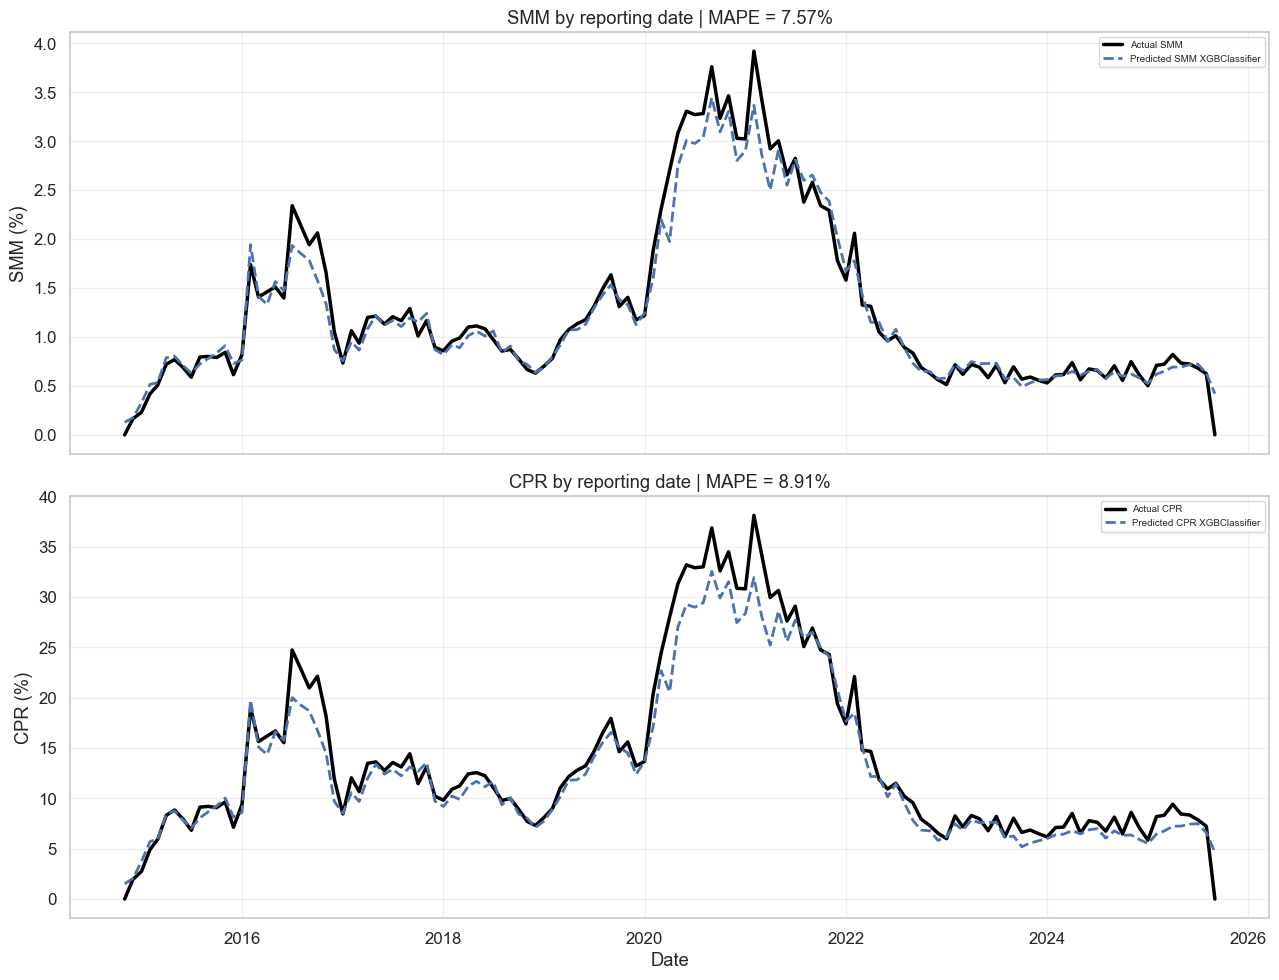

In [19]:
plot_smm_cpr(test_pd, X_test, model)

In [34]:
def plot_smm_cpr(test_pd, X_test, model):
    test_pd = test_pd.copy()

    agg = (
        test_pd.groupby("reporting_date")
        .agg(
            n=(TARGET_COL, "count"),
            n_prepaid=(TARGET_COL, "sum")
        )
        .reset_index()
    )
    agg["smm"] = agg["n_prepaid"] / agg["n"]
    agg["cpr"] = (1 - (1 - agg["smm"]) ** 12) * 100
    agg = agg.sort_values("reporting_date")

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

    a1.plot(
        agg["reporting_date"],
        agg["smm"] * 100,
        color="black",
        lw=2.5,
        label="Actual SMM"
    )
    a2.plot(
        agg["reporting_date"],
        agg["cpr"],
        color="black",
        lw=2.5,
        label="Actual CPR"
    )

    # --- predicted ---
    prob = model_inference(model, X_test)
    smm = _correct(prob)
    cpr = 1 - (1 - smm) ** 12

    test_pd["smm_pred"] = smm * 100
    test_pd["cpr_pred"] = cpr * 100

    agg2 = (
        test_pd.groupby("reporting_date")
        .agg(
            smm_pred=("smm_pred", "mean"),
            cpr_pred=("cpr_pred", "mean")
        )
        .reset_index()
        .sort_values("reporting_date")
    )

    a1.plot(
        agg2["reporting_date"],
        agg2["smm_pred"],
        lw=2.0,
        linestyle="--",
        label="Predicted SMM " + type(model).__name__
    )
    a2.plot(
        agg2["reporting_date"],
        agg2["cpr_pred"],
        lw=2.0,
        linestyle="--",
        label="Predicted CPR " + type(model).__name__
    )

    merged = agg.merge(agg2, on="reporting_date", how="inner")
    merged["smm_actual_pct"] = merged["smm"] * 100
    smm_mask = merged["smm_actual_pct"] != 0
    cpr_mask = merged["cpr"] != 0

    smm_mape = (
        np.abs(
            (merged.loc[smm_mask, "smm_actual_pct"] - merged.loc[smm_mask, "smm_pred"])
            / merged.loc[smm_mask, "smm_actual_pct"]
        ).mean() * 100
        if smm_mask.any() else np.nan
    )

    cpr_mape = (
        np.abs(
            (merged.loc[cpr_mask, "cpr"] - merged.loc[cpr_mask, "cpr_pred"])
            / merged.loc[cpr_mask, "cpr"]
        ).mean() * 100
        if cpr_mask.any() else np.nan
    )

    a1.set_title(f"SMM by reporting date | MAPE = {smm_mape:.2f}%")
    a2.set_title(f"CPR by reporting date | MAPE = {cpr_mape:.2f}%")

    a1.set_ylabel("SMM (%)")
    a1.legend(fontsize=7)
    a1.grid(alpha=0.3)

    a2.set_ylabel("CPR (%)")
    a2.set_xlabel("Date")
    a2.legend(fontsize=7)
    a2.grid(alpha=0.3)

    fig.tight_layout()

In [35]:
model_dir = os.path.join(out_path, "saved_models")

In [36]:
lr_model = load_model(os.path.join(model_dir, "lr.pkl"))
rf_model = load_model(os.path.join(model_dir, "rf.pkl"))
sgd_model = load_model(os.path.join(model_dir, "sgd.pkl"))
xgb_model = load_model(os.path.join(model_dir, "xgb.pkl"))
lgb_model = load_model(os.path.join(model_dir, "lgb.pkl"))
stc_model = load_model(os.path.join(model_dir, "stacking.pkl"))
cal_model = load_model(os.path.join(model_dir, "calibrated.pkl"))

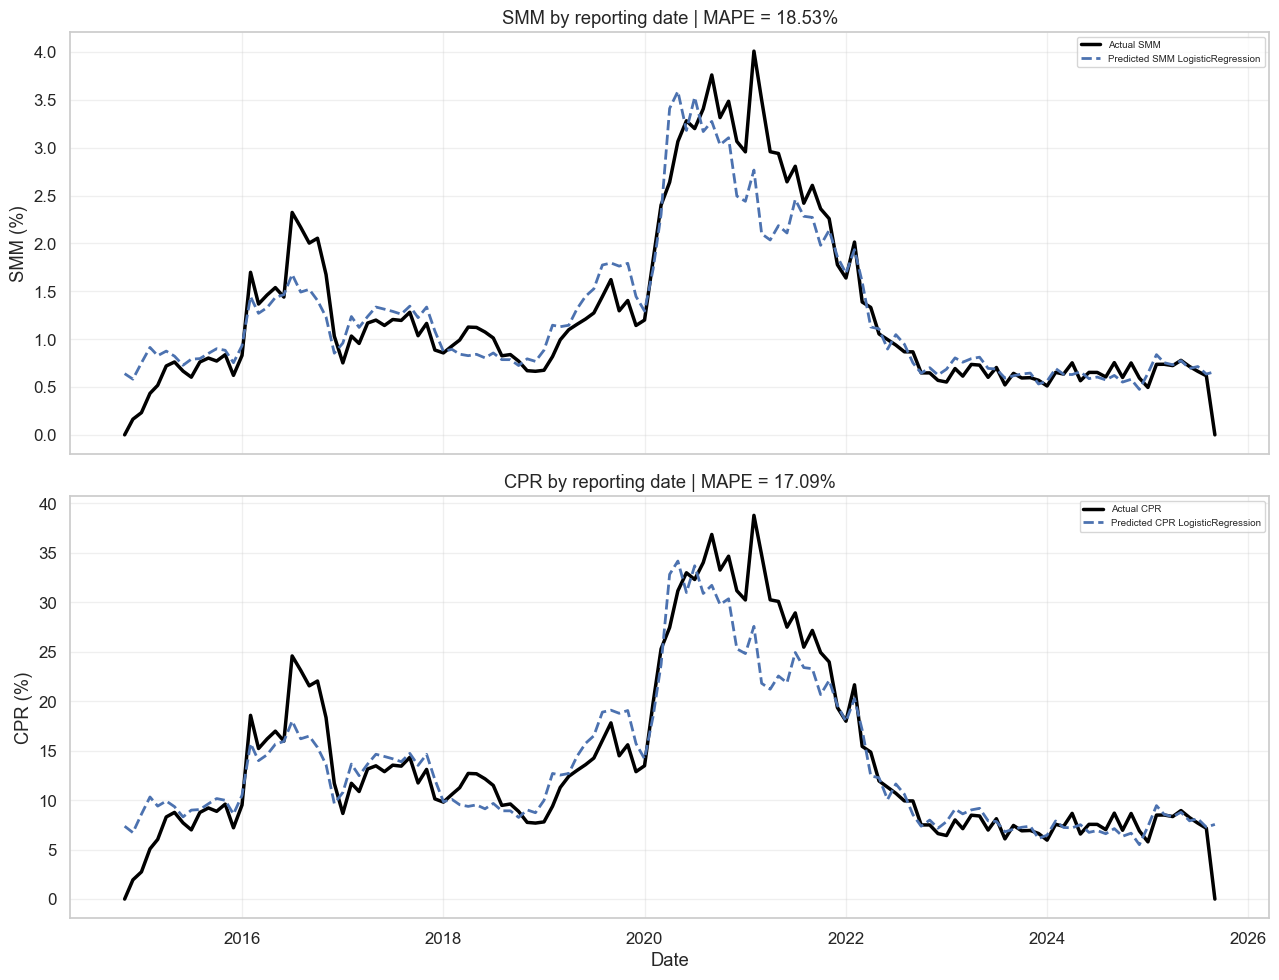

In [47]:
plot_smm_cpr(test_pd, X_test, lr_model)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.9s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   17.2s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   28.4s finished


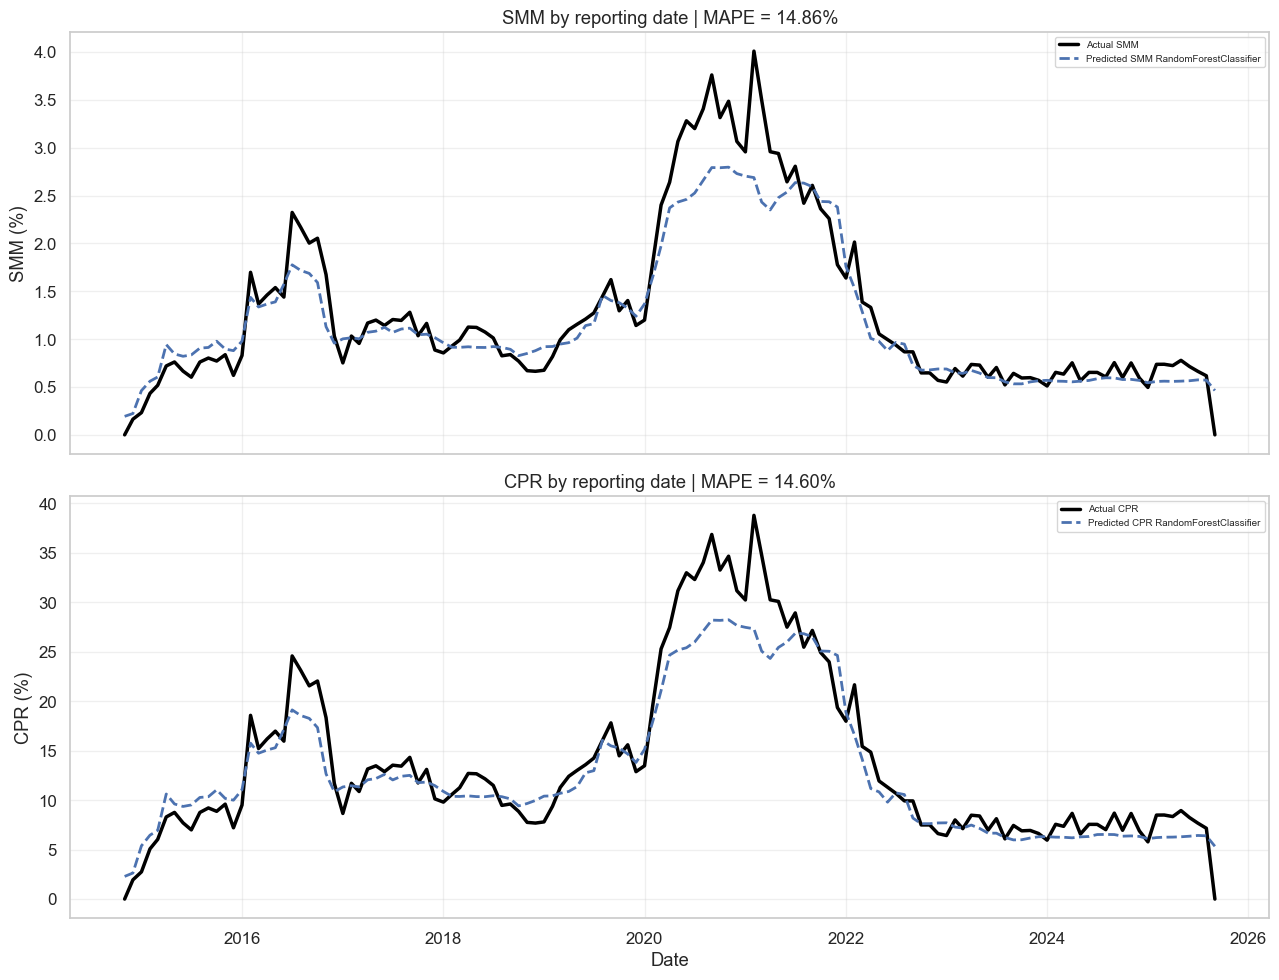

In [48]:
plot_smm_cpr(test_pd, X_test, rf_model)

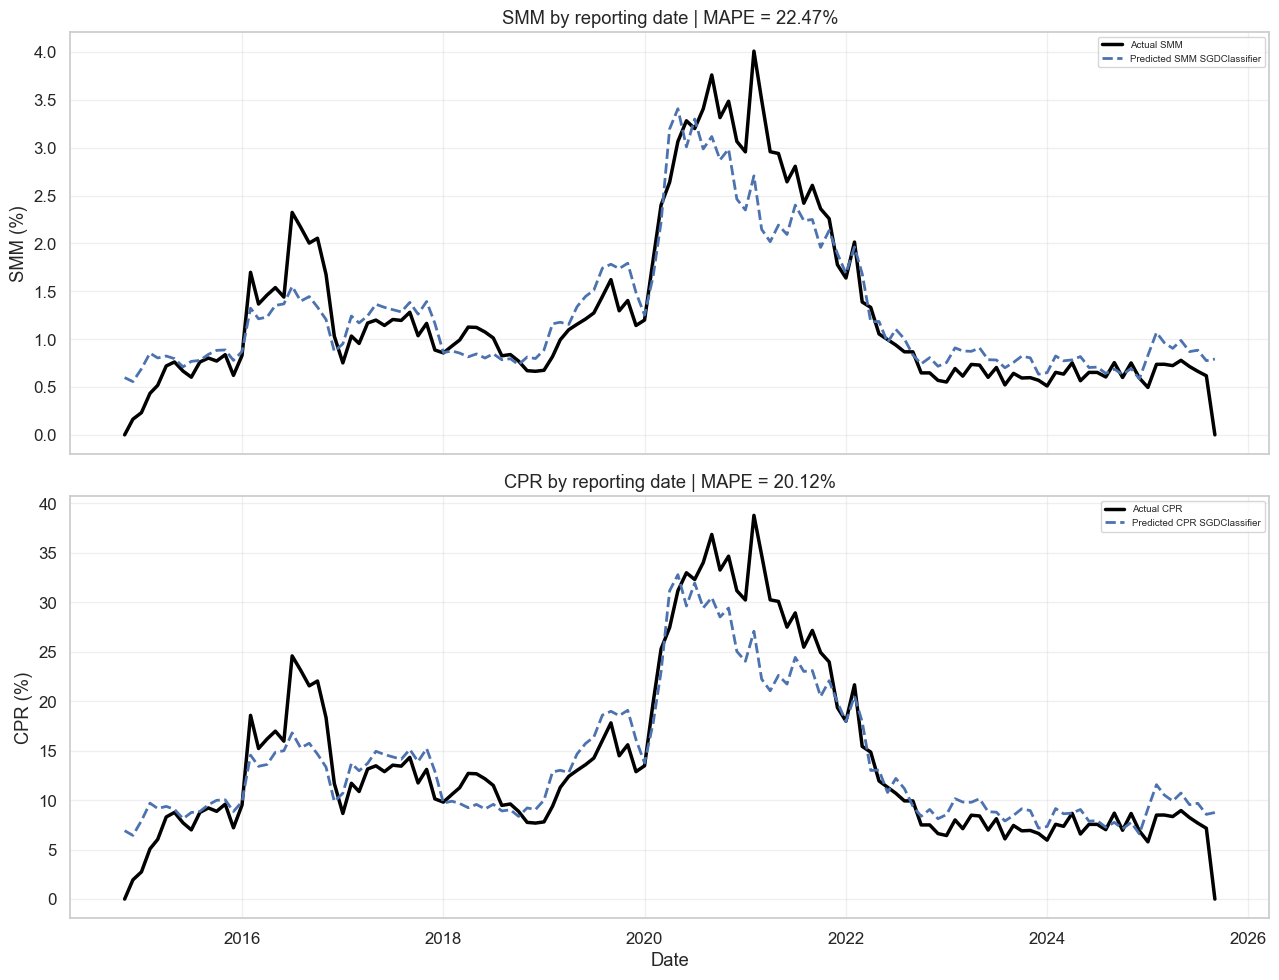

In [49]:
plot_smm_cpr(test_pd, X_test, sgd_model)

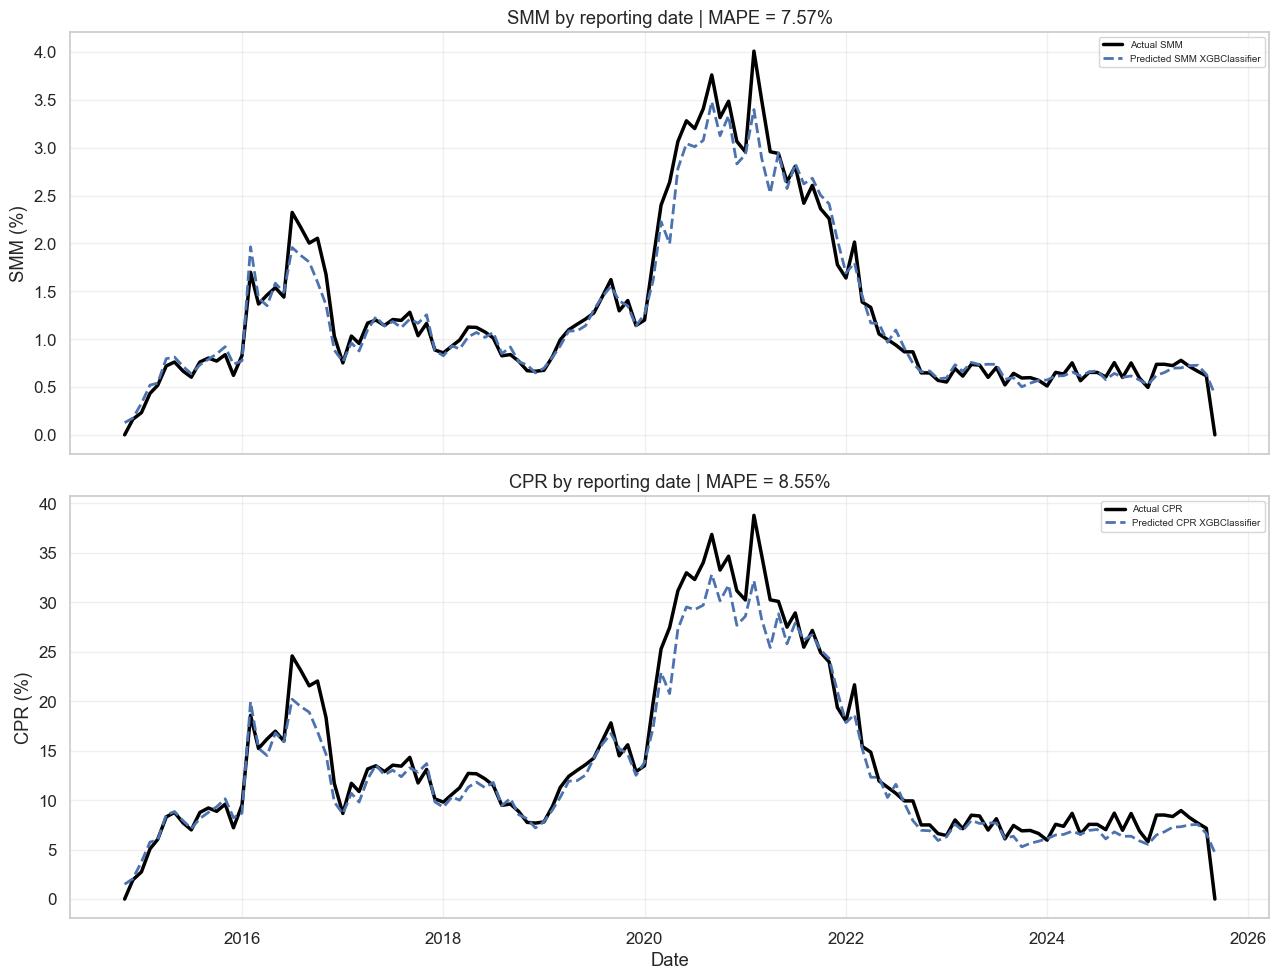

In [50]:
plot_smm_cpr(test_pd, X_test, xgb_model)

C:\Users\paine\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


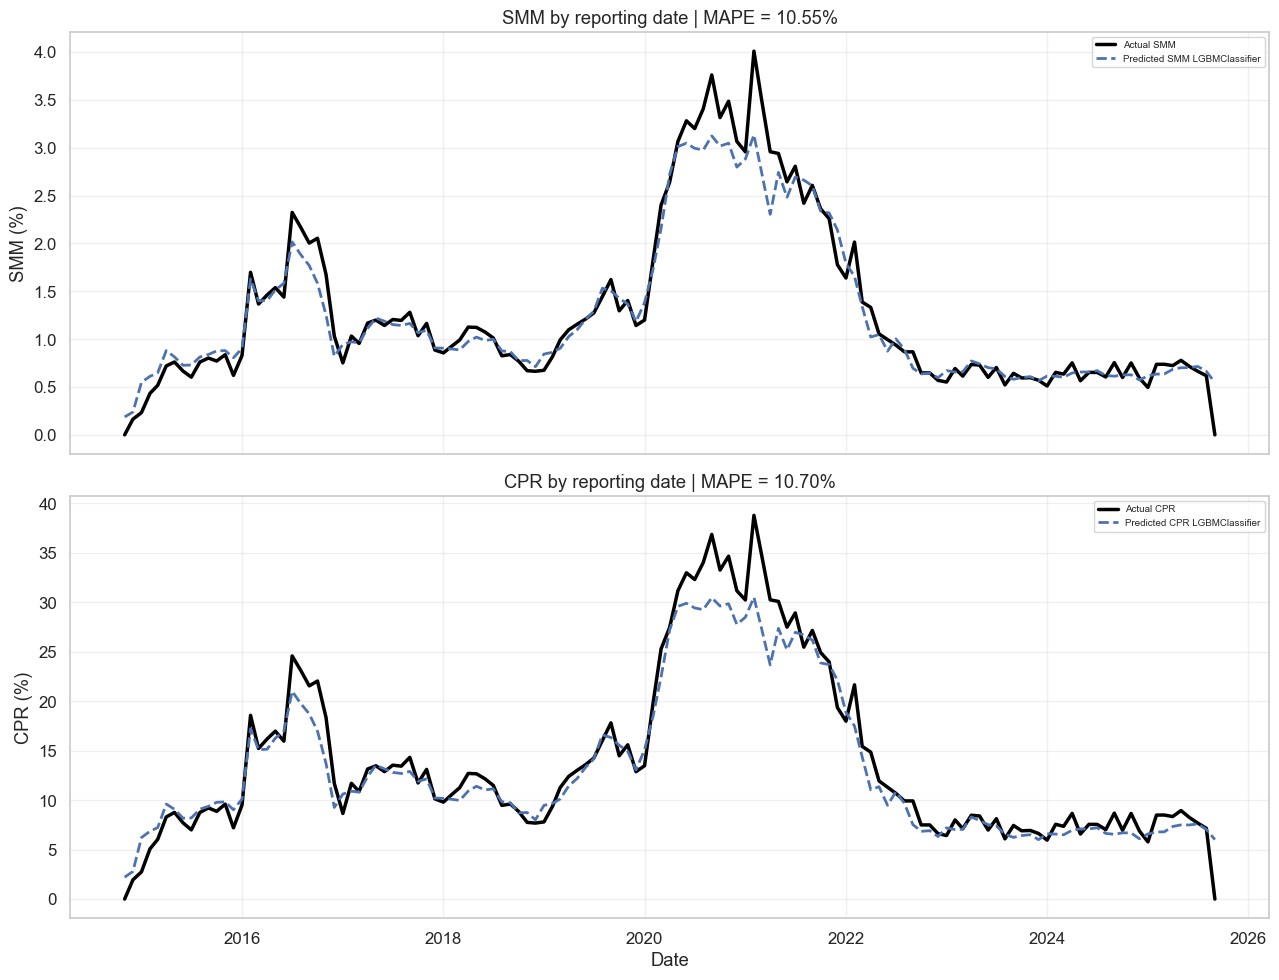

In [51]:
plot_smm_cpr(test_pd, X_test, lgb_model)

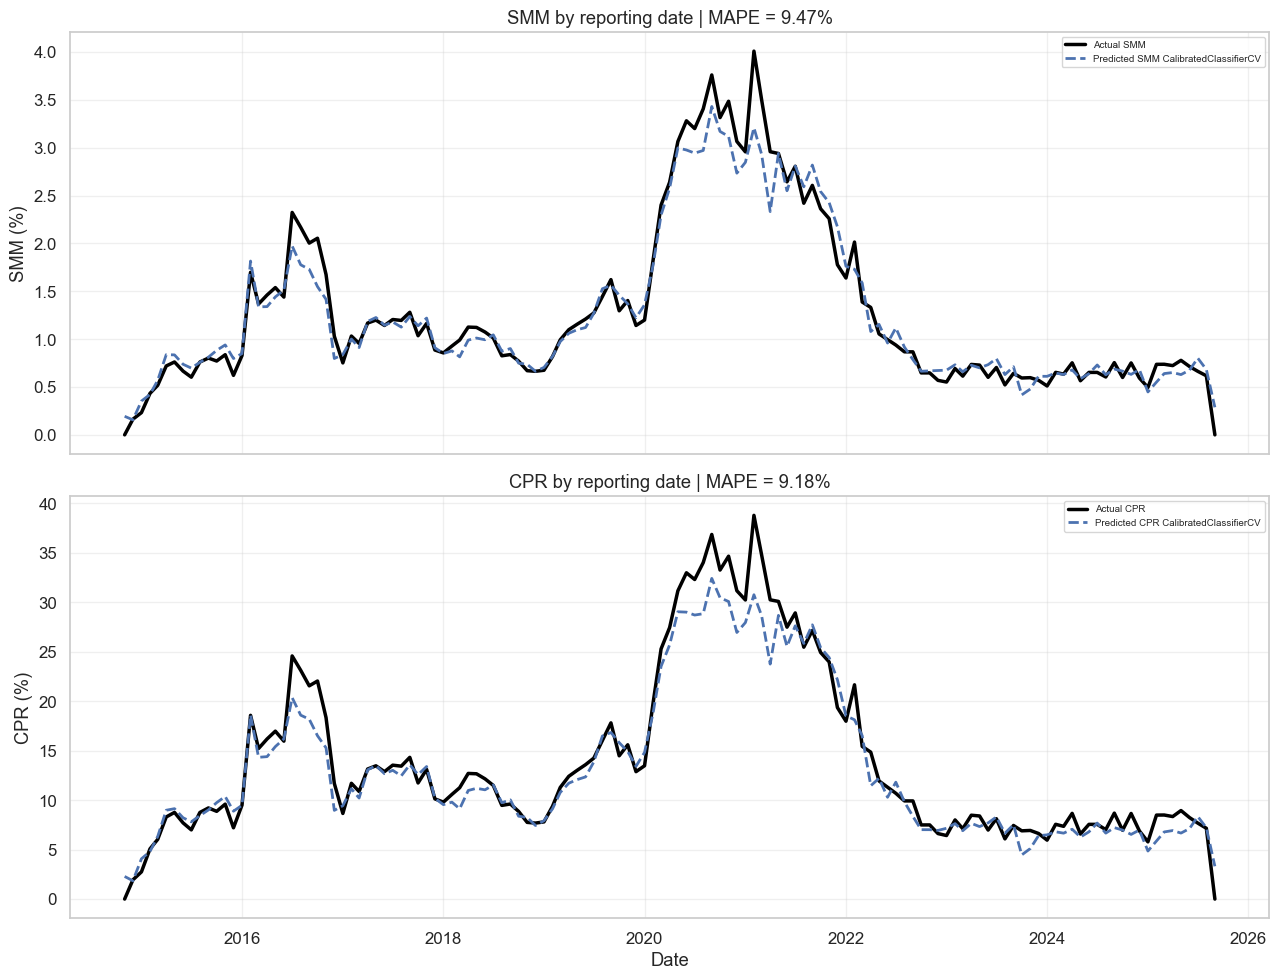

In [44]:
def _correct(p):
    w = 1
    return p / (w * (1.0 - p) + p)
plot_smm_cpr(test_pd, X_test, cal_model)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.9s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   19.4s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   33.9s finished
C:\Users\paine\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


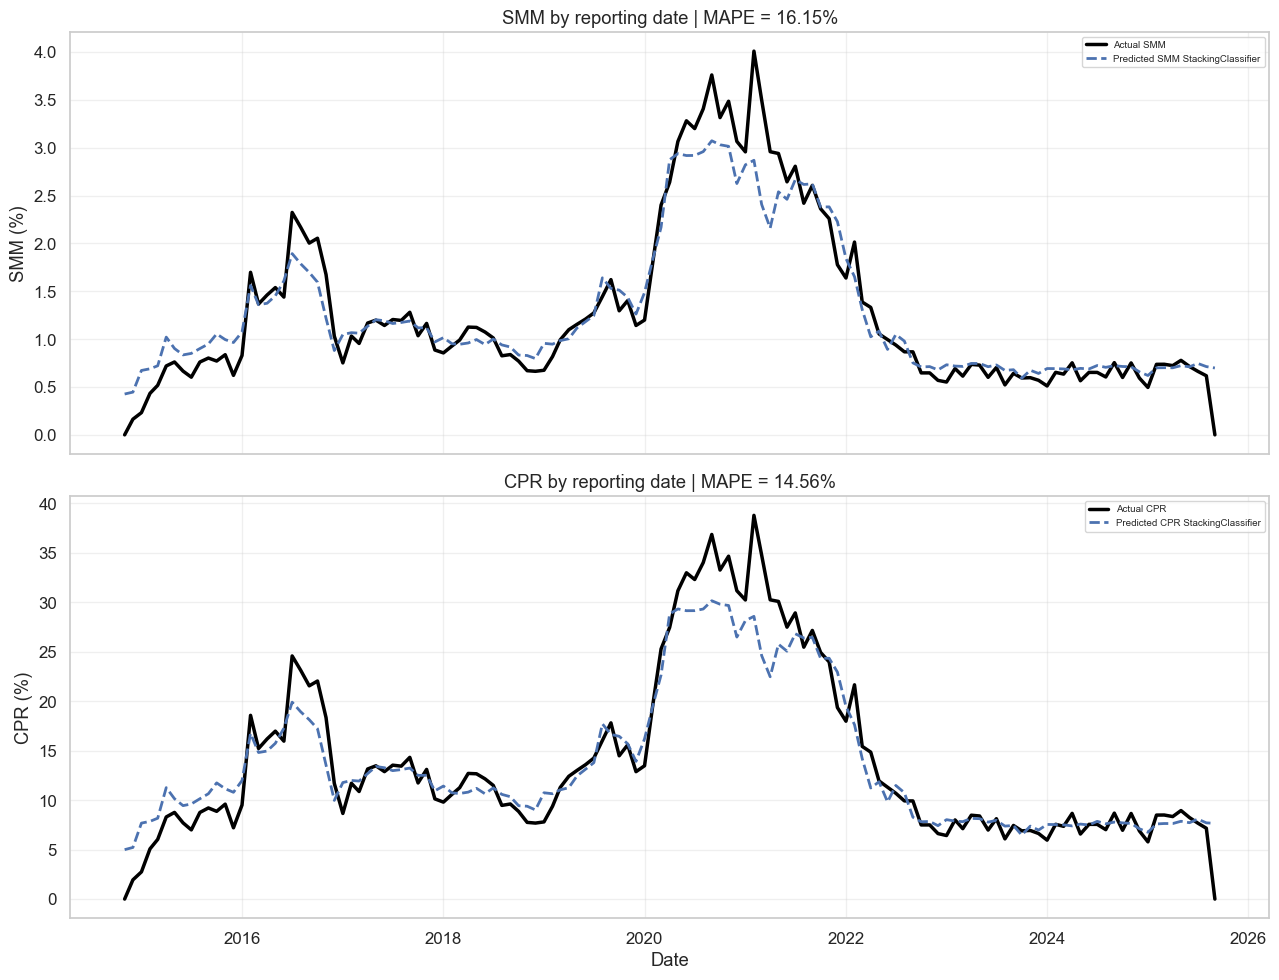

In [45]:
plot_smm_cpr(test_pd, X_test, stc_model)

In [26]:
class WeightedAverageModel:
    def __init__(self, fitted_models, weights, name="Soft Voting"):
        self.fitted_models = fitted_models
        self.weights = weights
        self.name = name

    def _predict_vector(self, X):
        weighted_preds = []
        active_weights = []

        for name, model in self.fitted_models.items():
            weight = self.weights.get(name, 0.0)
            if model is None or weight == 0:
                continue

            p = model.predict_proba(X)[:, 1]
            weighted_preds.append(weight * p)
            active_weights.append(weight)
            log.info("  %s -> weight=%.2f, mean=%.4f", name, weight, p.mean())

        total_weight = sum(active_weights)
        if total_weight <= 0:
            raise ValueError("Sum of active weights must be positive.")

        return sum(weighted_preds) / total_weight

    def predict_proba(self, X):
        p = np.clip(self._predict_vector(X), 0.0, 1.0)
        return np.column_stack([1.0 - p, p])


def make_weighted_average_model(fitted_models, weights):
    return WeightedAverageModel(fitted_models=fitted_models, weights=weights)


soft_voting_weights = {
    "xgb": 0.5,
    "lgb": 0.35,
    "sgd": 0,
    "rf": 0.15,
    "lr": 0,
}

soft_voting_base_models = {
    "xgb": xgb_model,
    "lgb": lgb_model,
    "sgd": sgd_model,
    "rf": rf_model,
    "lr": lr_model,
}

soft_voting_model = make_weighted_average_model(
    soft_voting_base_models,
    weights=soft_voting_weights,
)
soft_voting_p = soft_voting_model.predict_proba(X_test)[:, 1]


2026-05-12 00:26:25,197 [INFO]   xgb -> weight=0.50, mean=0.4085
C:\Users\paine\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-05-12 00:26:40,658 [INFO]   lgb -> weight=0.35, mean=0.4221
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   12.5s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   21.3s finished
2026-05-12 00:27:02,332 [INFO]   rf -> weight=0.15, mean=0.4336


2026-05-12 00:27:24,671 [INFO]   xgb -> weight=0.50, mean=0.4085
C:\Users\paine\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-05-12 00:27:40,082 [INFO]   lgb -> weight=0.35, mean=0.4221
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   12.3s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   20.6s finished
2026-05-12 00:28:01,015 [INFO]   rf -> weight=0.15, mean=0.4336


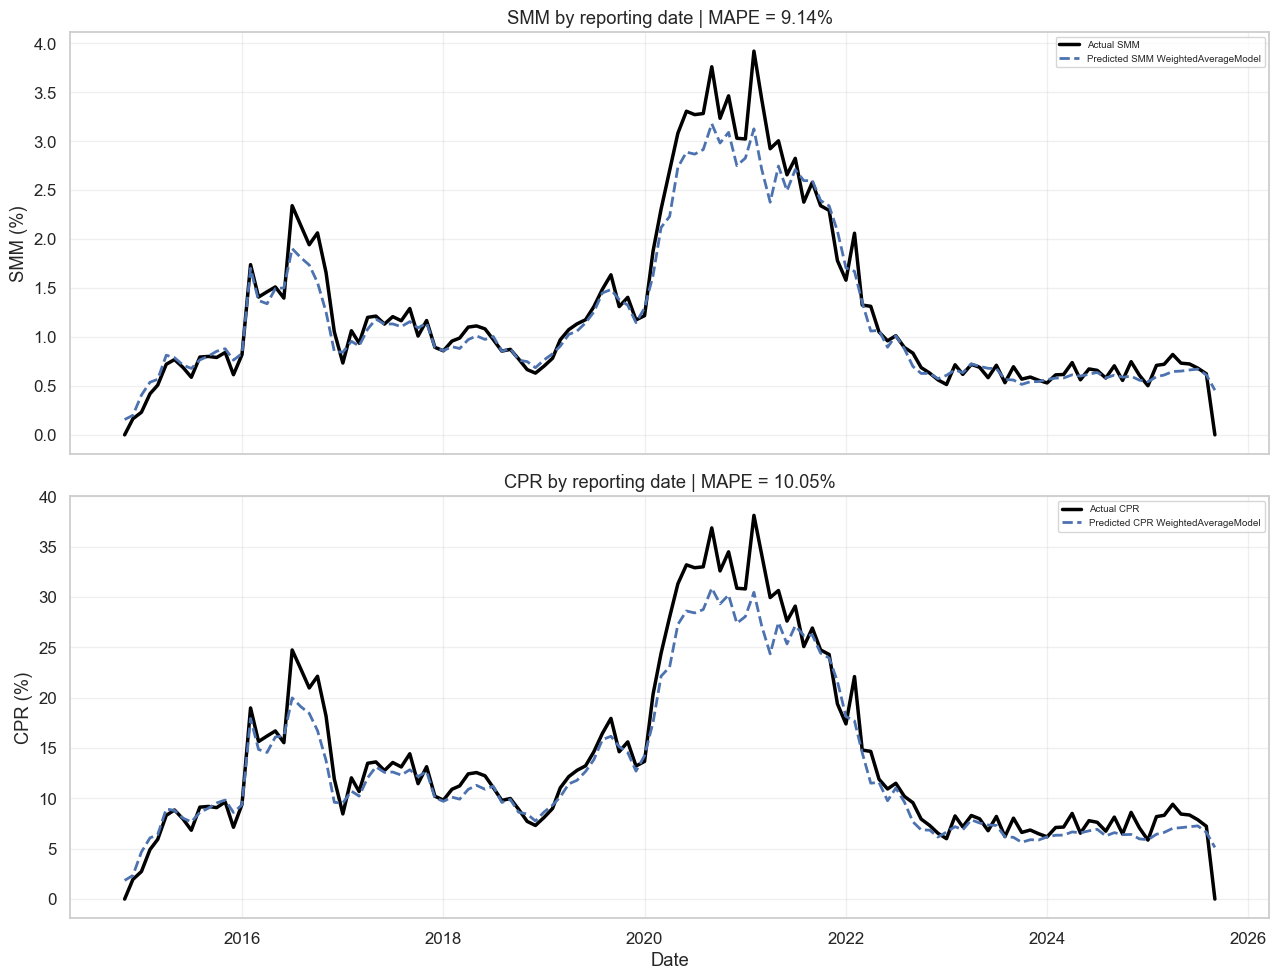

In [27]:
plot_smm_cpr(test_pd, X_test, soft_voting_model)